> Reproducing this notebook
>
>   1. Run the pipeline to generate walkforward_results_*.csv and debug exports
>   2. Run this notebook (it is read-only on the artifacts)


In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from utils import (
    load_results_csv,
    load_equity_debug,
    plot_equity_vs_spikes,
    plot_selected_timeline,
)

# --- Figures setup ---
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False


def _ensure_datetime(df: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    df = df.copy()
    if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


def slice_date_window(df: pd.DataFrame, start: str | None = None, end: str | None = None) -> pd.DataFrame:
    """Slice a debug equity dataframe by date strings like '2016-03-01'..'2016-08-31'."""
    df = _ensure_datetime(df, "date")
    if start is not None:
        df = df[df["date"] >= pd.to_datetime(start)]
    if end is not None:
        df = df[df["date"] <= pd.to_datetime(end)]
    return df


def preview_rows(df: pd.DataFrame, n: int = 10, cols: list[str] | None = None) -> pd.DataFrame:
    if cols is None:
        cols = [
            "date",
            "equity_baseline",
            "equity_dynamic",
            "selected_type",
            "signal_prev",
            "spike",
            "near_spike",
        ]
    out = df[cols].copy()
    out["date"] = pd.to_datetime(out["date"]).dt.date
    return out.head(n)


def describe_spikes(df: pd.DataFrame) -> pd.DataFrame:
    df = _ensure_datetime(df, "date")
    n = len(df)
    spike_rate = float(np.mean(df["spike"])) if ("spike" in df and n) else np.nan
    near_rate = float(np.mean(df["near_spike"])) if ("near_spike" in df and n) else np.nan
    return pd.DataFrame([{
        "rows": n,
        "spike_rate": spike_rate,
        "near_spike_rate": near_rate,
        "vol_thr": float(df["vol_thr"].iloc[0]) if ("vol_thr" in df and n) else np.nan,
        "near_thr": float(df["near_thr"].iloc[0]) if ("near_thr" in df and n) else np.nan,
    }])


def load_equity_debug_compat(pair: str, fold: int | None = None, fold_id: int | None = None) -> pd.DataFrame:
    """Accepts fold= or fold_id= to avoid call-site mistakes."""
    if fold is None and fold_id is None:
        raise ValueError("Pass fold=<int> or fold_id=<int>.")
    if fold is None:
        fold = fold_id
    return load_equity_debug(pair=pair, fold=int(fold))

---

# Part A — What / why / how (fast skim)

---

# 1. Regime-Aware Strategy Selection (Mixture-of-Experts Gating)  
## Leakage-safe walk-forward evaluation + robustness mitigations (volatility guard, max-hold reset)

**One-liner:** A time-series ML system that routes between expert trading policies (Trend Following vs Mean Reversion vs a rule-based baseline) using an XGBoost gating model, evaluated with **leakage-safe** walk-forward backtesting and hardened against two practical failure modes.

**What this notebook is:** a recruiter-friendly, end-to-end “systems + evaluation” walkthrough.  
**What it is not:** a promise of profits.

---

## 2) Executive summary (quick skim)

**What this is:**  
A regime-aware **mixture-of-experts gating** system for a non-stationary time series decision problem. It routes between pre-defined expert strategy families (Trend-Following vs Mean-Reversion vs a rule-based router) using an **XGBoost classifier**, evaluated with **leakage-safe walk-forward** backtesting.

**Why this matters (ML engineering angle):**
- In non-stationary settings, the “best” policy changes over time → the problem becomes **strategy selection** under changing conditions.
- The hard part is not training a model — it’s building a **correct evaluation harness** (no leakage) and handling **failure modes** in online decision routing.

**Core approach:**
- **Rule-based regime labeling** (ADX + ATR%) for interpretable market phases.
- **Supervised gating model** (XGBoost) predicts which policy family is likely to perform best over a fixed horizon.
- **Online routing logic** adds practical controls:
  - confidence gating (τ_enter / τ_exit hysteresis)
  - minimum hold (reduce churn)
  - **volatility guard** (avoid MR during volatility spikes; threshold computed per fold on training only)
  - **max-hold reset** (avoid lock-in; `max_hold_bars = 60`, applied only when flat)

**Primary evaluation (what to trust):**
- Expanding-window walk-forward evaluation across **14 FX pairs** (~20y daily data).
- Fold-level comparisons against a strong baseline (**PhaseAware TF/MR**).

**Headline result snapshot (run46 default):**
- Dynamic selector vs PhaseAware baseline shows a **small but positive average uplift** in risk-adjusted performance.
- Improvements are not uniform — the value comes from specific regimes, and some folds still get worse (expected for gating systems).

**Artifacts produced:**
- Reproducible CSV outputs (per-fold, per-pair, summary tables)
- Debug equity / selection timeline exports for case studies and failure analysis

> Note: This is a portfolio / engineering project. The goal is demonstrating a robust ML + evaluation workflow on non-stationary time series, not “promising profits”.

---

## 3) Problem framing: regime shifts → “which strategy should run next?”

Many real-world time series problems are **non-stationary**: the data-generating process changes, and what works in one period can fail in another.

In trading terms:
- **Trend-following** tends to work better in persistent directional markets.
- **Mean-reversion** can work better in ranging / oscillatory markets.
- A single fixed strategy is often a poor fit across all regimes.

This project reframes the task as a **policy routing** problem:

> At each time step, given current context features, decide which “expert” policy family to execute next.

That is a classic **mixture-of-experts** pattern:
- Experts = hand-designed strategy families (TF, MR, and a rule-based PhaseAware router).
- Gating model = an ML classifier that selects the expert family likely to perform best over a fixed horizon.
- Evaluation = walk-forward backtesting with strict leakage controls (because time series leakage is easy to introduce accidentally).

The practical challenge is not only prediction accuracy — it’s **robust decision-making** under changing conditions:
- How do we avoid churn (over-switching)?
- How do we prevent catastrophic mistakes in rare conditions (e.g., volatility spikes)?
- How do we evaluate fairly without peeking into the future?

---

### 4. What is a fold?

A **fold** is one out-of-sample evaluation step in a **walk-forward** backtest.

For each fold:
- Train the gating model on an expanding historical window (e.g., the prior 7 years).
- Test on the next time window (e.g., the next 6 months).
- Slide forward and repeat.

This mimics how a real system would be retrained over time and avoids leaking future information into the past.

---

# Part B — Evidence

---

## 1. Load artifacts (CSV tables)

> What these tables represent (leakage-safe):
> All reported metrics come from walk-forward folds. For each fold, the gating model and any thresholds (e.g., the volatility guard
> quantile threshold) are fit on that fold’s training window only, then evaluated on the subsequent test window.
>
> The key analysis unit is the fold: it’s the closest thing to a repeated out-of-sample experiment.

In [2]:
summary = load_results_csv("walkforward_results_summary.csv")
per_pair = load_results_csv("walkforward_results_per_pair.csv")
per_fold = load_results_csv("walkforward_results_per_fold.csv")

summary

,Pairs,Folds,Avg Return Δ,Avg Sharpe Δ,Avg Max DD Δ,Folds Sharpe Improved
0,14,361,0.194875,0.084359,-0.167313,192


## 2. Results (global)

> Metric conventions used here
>
> - Return Δ / Sharpe Δ / DD Δ are computed as (Dynamic − Baseline) at the fold level.
> - Max DD (%) is stored as a negative number (e.g., −30%).
> - Therefore positive DD Δ means Dynamic had a less negative drawdown → better.


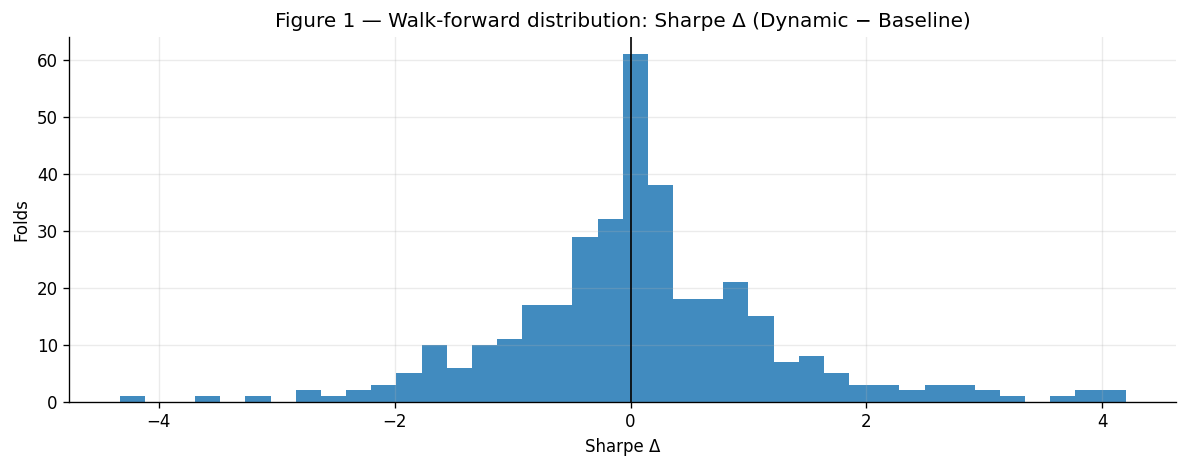

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
x = per_fold["Sharpe Δ"].dropna().astype(float)

ax.hist(x, bins=40, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Figure 1 — Walk-forward distribution: Sharpe Δ (Dynamic − Baseline)")
ax.set_xlabel("Sharpe Δ")
ax.set_ylabel("Folds")

plt.tight_layout()
plt.show()

> Most folds cluster near 0 Sharpe Δ (expected). The goal is not to win every fold, but to gain edge in specific regimes without blowing up in others.

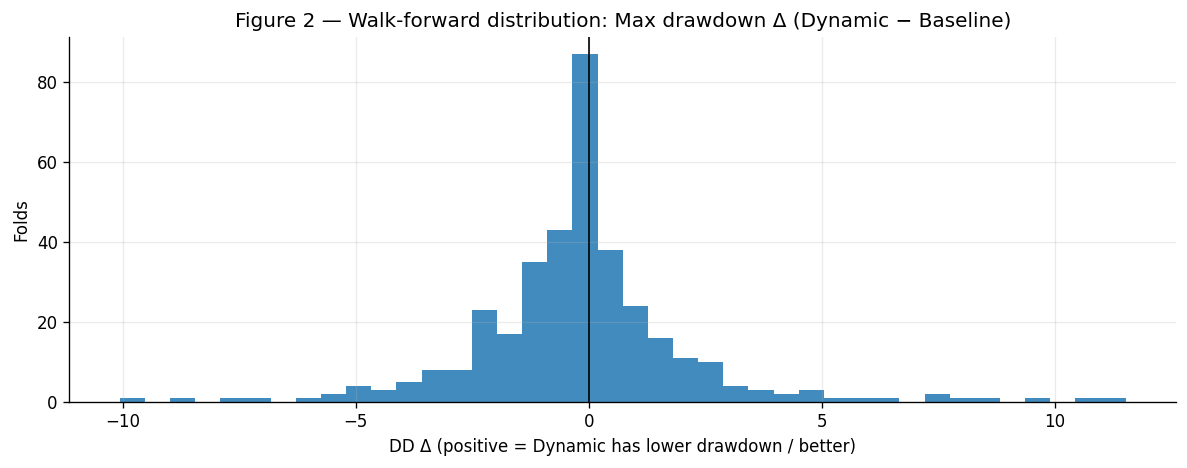

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
x = per_fold["DD Δ"].dropna().astype(float)

ax.hist(x, bins=40, alpha=0.85)
ax.axvline(0, color="black", linewidth=1)

ax.set_title("Figure 2 — Walk-forward distribution: Max drawdown Δ (Dynamic − Baseline)")
ax.set_xlabel("DD Δ (positive = Dynamic has lower drawdown / better)")
ax.set_ylabel("Folds")

plt.tight_layout()
plt.show()

> With DD stored as negative %, DD Δ > 0 is better (Dynamic has less drawdown).
> 
> This plot is mainly a safety check: improvements shouldn’t come from rare catastrophic tails.

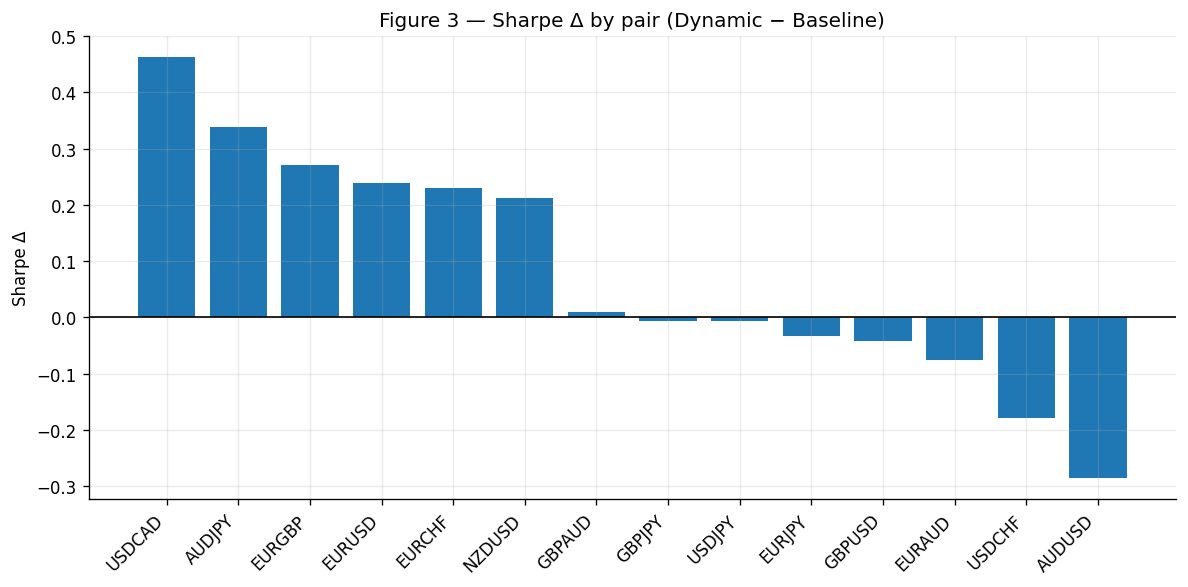

In [5]:
pp = per_pair.copy()
pp["Sharpe Δ"] = pp["Sharpe Δ"].astype(float)
pp_sorted = pp.sort_values("Sharpe Δ", ascending=False).reset_index(drop=True)

pairs = pp_sorted["Pair"].tolist()
vals = pp_sorted["Sharpe Δ"].tolist()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pairs))

ax.bar(x, vals)
ax.axhline(0, color="black", linewidth=1)

ax.set_title("Figure 3 — Sharpe Δ by pair (Dynamic − Baseline)")
ax.set_ylabel("Sharpe Δ")
ax.set_xticks(x)
ax.set_xticklabels(pairs, rotation=45, ha="right")

plt.tight_layout()
plt.show()

> Per-pair results vary. This notebook focuses on a global selector configuration (run46) that behaves reasonably across pairs rather than tuning per instrument.

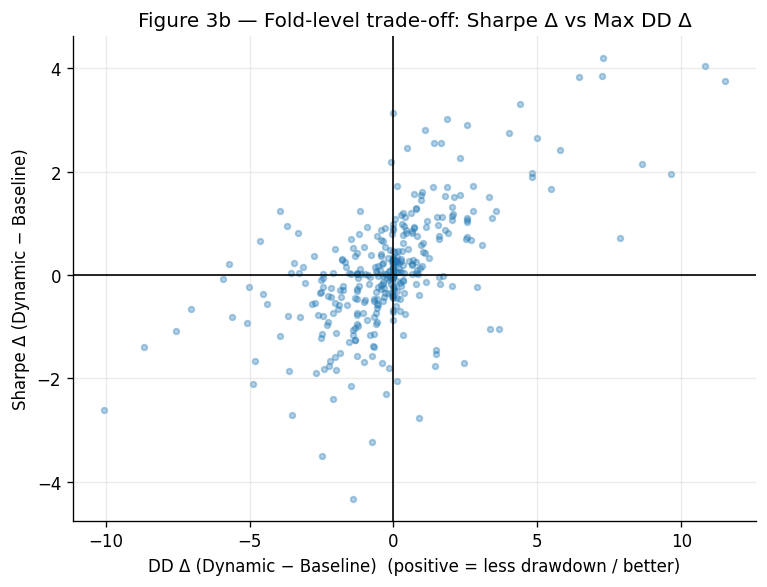

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5))
df = per_fold.copy()
df["Sharpe Δ"] = df["Sharpe Δ"].astype(float)
df["DD Δ"] = df["DD Δ"].astype(float)

ax.scatter(df["DD Δ"], df["Sharpe Δ"], s=12, alpha=0.35)
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Figure 3b — Fold-level trade-off: Sharpe Δ vs Max DD Δ")
ax.set_xlabel("DD Δ (Dynamic − Baseline)  (positive = less drawdown / better)")
ax.set_ylabel("Sharpe Δ (Dynamic − Baseline)")
plt.tight_layout()
plt.show()

---

# Part C — Failure modes

---

## Case study: GBPJPY fold 8 (debug exports)

This section uses the debug CSV export (results/equity_debug_{pair}_fold{fold}.csv) to visualize why the selector behaves the way it does in one specific walk-forward fold.

We plot:

    - Equity curves for baseline vs dynamic selector
    - The volatility spike mask (spike, near_spike) derived from ATR% and the fold-specific training quantile threshold
    - (Optionally) the selected strategy timeline, to confirm that the volatility guard and gating logic behave as intended

    Note on leakage safety: the volatility threshold is computed on the training slice only for that fold (quantile q), then applied to the test slice.

---

> What “spike” means in the plots:
> 
> spike=True marks bars where volatility (ATR%) exceeds a fold-specific threshold learned on the training window only (quantile-based).
> 
> near_spike=True is an early-warning band (a multiple of the threshold).
> 
> This is explicitly designed to be leakage-safe: thresholds are computed without using any test-window data.

In [7]:
pair = "GBPJPY"
fold = 8

eq8 = load_equity_debug_compat(pair=pair, fold=fold)
eq8 = _ensure_datetime(eq8, "date")

eq8_zoom = slice_date_window(eq8, start="2016-03-01", end="2016-08-31")

describe_spikes(eq8_zoom)

,rows,spike_rate,near_spike_rate,vol_thr,near_thr
0,123,0.97561,1.0,1.432189,1.28897


In [12]:
def preview_interesting_rows(df: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    df = _ensure_datetime(df, "date").copy()

    # detect changes
    eq_dyn = df["equity_dynamic"].astype(float)
    eq_base = df["equity_baseline"].astype(float)

    changed = (
        df["selected_type"].ne(df["selected_type"].shift(1))
        | eq_dyn.ne(eq_dyn.shift(1))
        | eq_base.ne(eq_base.shift(1))
        | df["spike"].ne(df["spike"].shift(1))
        | df["near_spike"].ne(df["near_spike"].shift(1))
    )

    out = df.loc[changed, [
        "date",
        "equity_baseline",
        "equity_dynamic",
        "selected_type",
        "signal_prev",
        "spike",
        "near_spike",
    ]].copy()

    out["date"] = pd.to_datetime(out["date"]).dt.date
    return out.head(n)

preview_interesting_rows(eq8_zoom, n=25)

,date,equity_baseline,equity_dynamic,selected_type,signal_prev,spike,near_spike
69,2016-05-25,9846.960604,9629.518593,TrendFollowing,0,True,True
71,2016-05-27,9846.348520,9629.518593,PhaseAware,0,True,True
72,2016-05-30,9846.348520,9628.924068,PhaseAware,-1,True,True
74,2016-06-01,9906.960125,9748.075343,PhaseAware,-1,True,True
75,2016-06-02,9967.934071,9868.685077,PhaseAware,-1,True,True
76,2016-06-03,10029.274322,9990.773362,PhaseAware,-1,True,True
77,2016-06-06,10090.975866,10114.353758,PhaseAware,-1,True,True
78,2016-06-07,9963.876498,9860.217167,PhaseAware,1,True,True
82,2016-06-13,9838.348008,9612.424595,TrendFollowing,1,True,True
83,2016-06-14,9838.348008,9597.475087,TrendFollowing,0,True,True


In [13]:
eq8_zoom["selected_type"].value_counts(dropna=False)

selected_type
TrendFollowing    19
PhaseAware        11
Name: count, dtype: int64

In [14]:
eq8_zoom[["spike","near_spike"]].mean()

spike         1.0
near_spike    1.0
dtype: float64

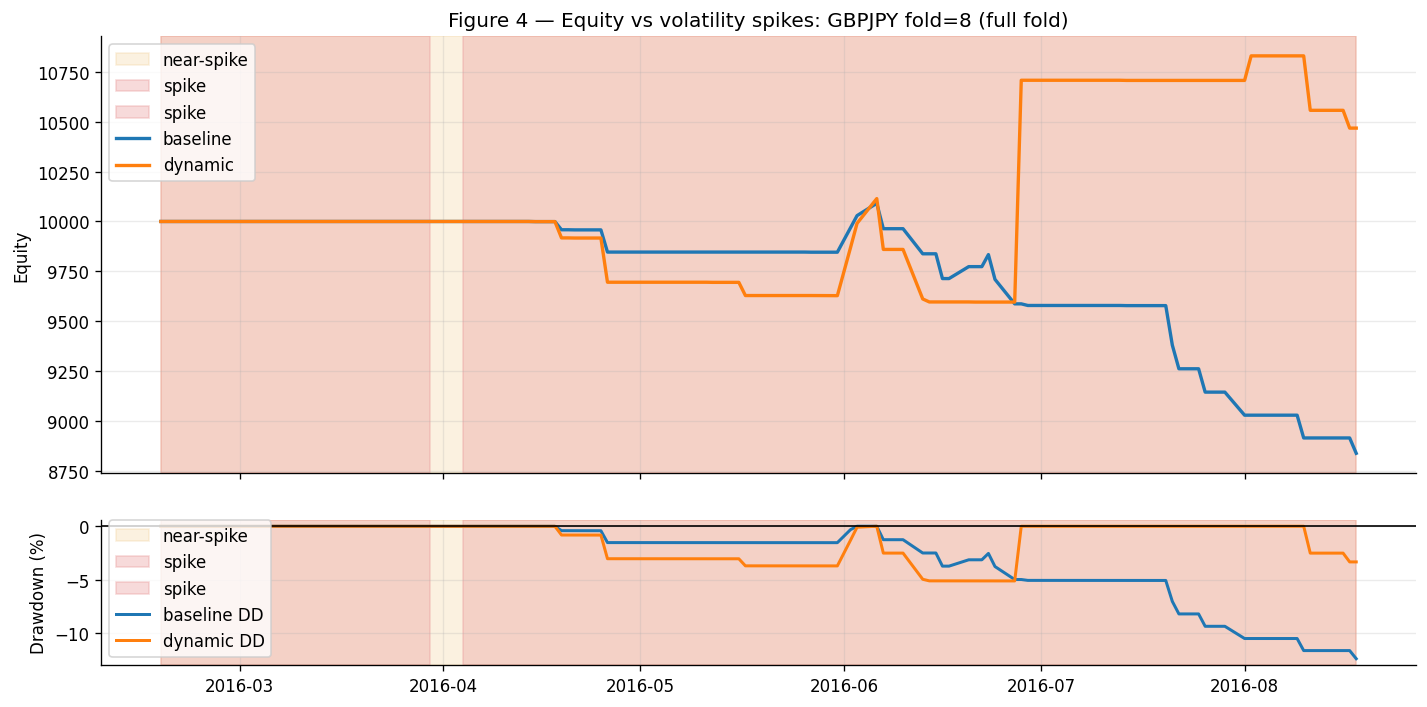

In [12]:
pair = "GBPJPY"
fold = 8

eq8 = load_equity_debug_compat(pair=pair, fold=fold)
eq8 = _ensure_datetime(eq8, "date")

# --- Figure 4: full fold ---
ax = plot_equity_vs_spikes(eq8, f"Figure 4 — Equity vs volatility spikes: {pair} fold={fold} (full fold)")
plt.tight_layout()
plt.show()

**Fig 4:** “Full fold context; shows baseline vs dynamic equity and spike/near-spike shading.”

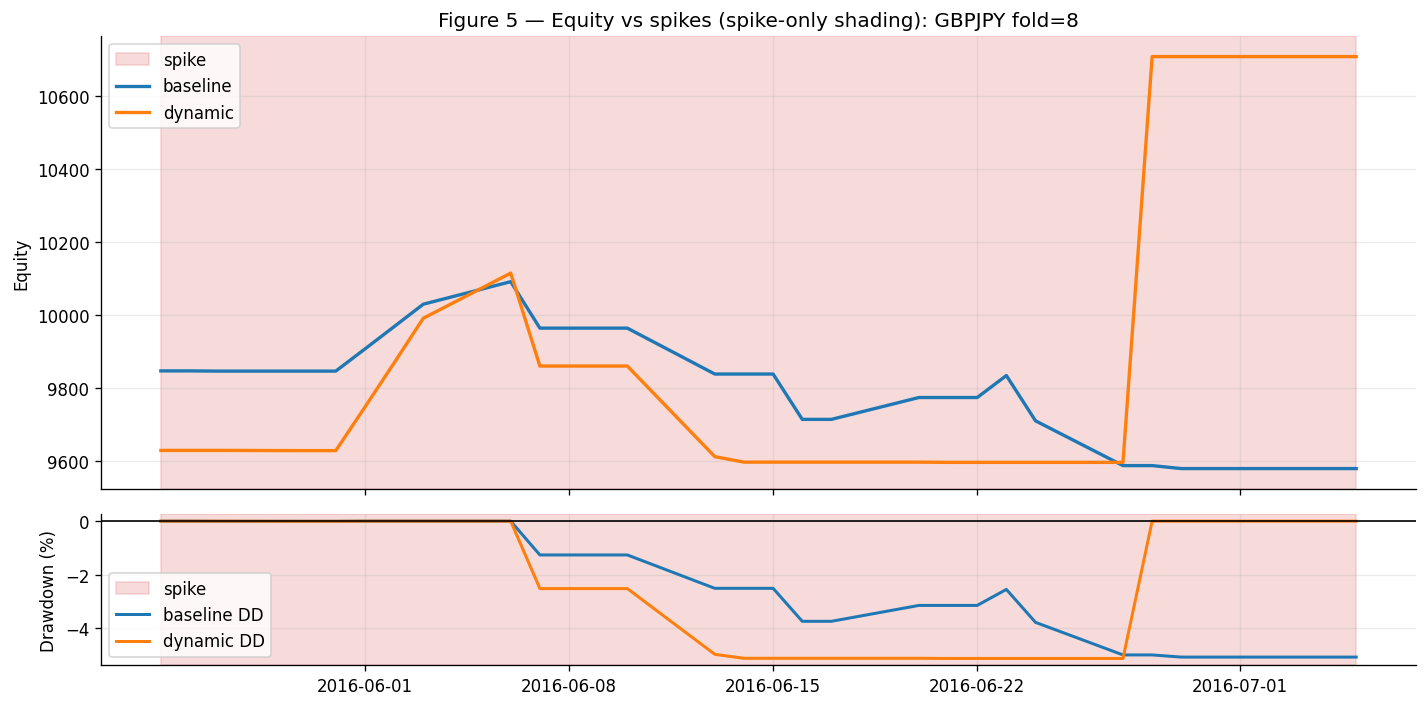

In [18]:
# --- Figure 5: zoom (narrow, actually different) ---
zoom_start = "2016-05-25"
zoom_end   = "2016-07-05"

eq8_zoom = slice_date_window(eq8, start=zoom_start, end=zoom_end)

eq8_zoom2 = eq8_zoom.copy()
eq8_zoom2["near_spike"] = False  # keep only spike shading for readability

plot_equity_vs_spikes(eq8_zoom2, f"Figure 5 — Equity vs spikes (spike-only shading): {pair} fold={fold}")
plt.tight_layout()
plt.show()

**Fig 5:** “Zoomed window where spikes + selections occur; easier to see guard behavior.”

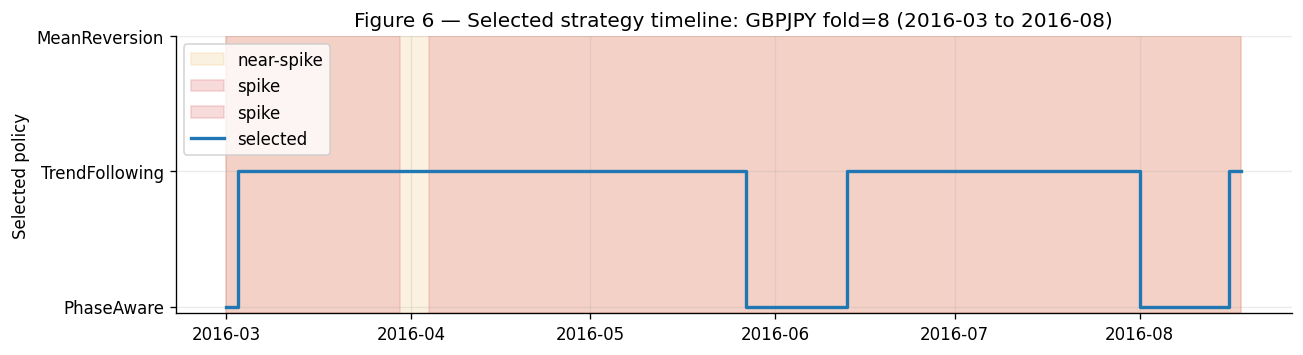

In [23]:
plot_selected_timeline(eq8_zoom, title=f"Figure 6 — Selected strategy timeline: {pair} fold={fold} (2016-03 to 2016-08)")
plt.show()

**Fig 6:** “Which expert family was active over time; verify reduced MR during spikes + switching behavior.”

> What to look for in this fold
> 
> - Whether MR selections are suppressed during spikes (guard doing its job).
> - Whether the selector thrashes (frequent switching) during noisy periods (potential churn).
> - Whether it locks in to TF/MR for too long → mitigated by max_hold_bars=60 (only when flat).


---

# Part D — Engineering highlights + next steps

---

## Engineering highlights (what I’d point recruiters to)

 - Leakage-safe evaluation harness: expanding-window walk-forward folds; per-fold training-only fitting for preprocessing and volatility thresholds.
 - Mixture-of-experts execution: hand-designed experts + ML gating + online routing logic (hysteresis, min-hold, confidence thresholds).
 - Robustness mitigations grounded in failure analysis:
       - volatility guard (prevents MR selection during spike regimes)
       - max-hold reset (max_hold_bars=60, only when flat) to avoid long lock-ins
 - Reproducible artifacts: per-fold / per-pair / summary CSVs, plus debug exports for equity curves and selection timelines to support “why did it do that?” analysis.
 - Ablations + runs tracked by run IDs: makes it possible to compare changes like a real ML system (not a single-off backtest).

## Limitations / caveats (what I’d improve next)

- Switching costs + slippage are not fully modeled (or could be made more realistic).
- Calibration: gating probabilities could be calibrated and used more systematically for position sizing / risk scaling.
- Decision latency & retrain schedule: explore different retrain frequencies and add “time-to-live” policies for models.
- Better uncertainty handling: e.g., abstain / fallback behavior when model confidence is low or regime is out-of-distribution.
